In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from torch.utils.data import TensorDataset, DataLoader, random_split
from models import CondSM
from tqdm import tqdm
import math
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [5]:
dataset_num = 0
dist_type = 'vMB_ring'
data_folder = 'data_vMB_ring_1e7'
data_dir = Path(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/') / data_folder
num_batches = 400
batch_size = 1024
train_size = 0.8
val_size = 0.1
test_size = 0.1
output_idx = 0

In [6]:
voltages = []
currents = []

for i in range(num_batches):

    fp = data_dir / f'batch_{i}.npz'
    try:
        batch = np.load(fp)
    except FileNotFoundError:
        continue        

    voltages.append(batch['inputs'])

    if batch['currents'].ndim != 1:
        currents.append(batch['currents'][:, output_idx])
    else:
        currents.append(batch['currents'])
        
vs = np.concatenate(voltages, axis=0)[..., [i for i in range(voltages[0].shape[1]) if i != output_idx]]
ys = np.concatenate(currents, axis=0)

V = torch.from_numpy(vs).float()

y = torch.from_numpy(ys).unsqueeze(-1).float()
print(V.shape)
print(y.shape)

dataset = TensorDataset(V, y)

generator_1 = torch.Generator().manual_seed(32)
train_ds, val_ds, test_ds = random_split(dataset, lengths=[train_size, val_size, test_size], generator=generator_1)

train_idx = train_ds.indices
y_train = y[train_idx]

mean = y_train.mean(dim=0)
std = y_train.std(dim=0)
print(mean)
print(std)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f"train_set: {len(train_loader.dataset)}")
print(f"val_set: {len(val_loader.dataset)}")
print(f"test_set: {len(test_loader.dataset)}")
print(torch.isnan(V[val_ds.indices]).any() or torch.isnan(y[train_ds.indices]).any())

torch.Size([200000, 7])
torch.Size([200000, 1])
tensor([-0.0456])
tensor([0.3179])
train_set: 160000
val_set: 20000
test_set: 20000
tensor(False)


In [7]:
layer_dims = [7, 90, 90, 90, 1]
dp = 0.1
bn = True
model = CondSM(layer_dims, dropout_p=dp, batch_norm=bn)
model = model.to(device)
print('model loaded')

model loaded


In [8]:
optimizer = torch.optim.Adam(
    model.parameters(), 
    lr=1e-3
)
criterion = nn.MSELoss()

normalize_output = True
mean = mean.to(device)
std = std.to(device)

train_losses = []
val_losses = []

num_epochs = 500

with tqdm(total=num_epochs, desc="Epochs") as pbar:
    for epoch in range(1, num_epochs + 1):
    
        model.train()
        running_loss = 0.0
        for v, y in train_loader:
            v = v.to(device, non_blocking=True).float()
            y = y.to(device, non_blocking=True).float()
            
            optimizer.zero_grad()
            
            preds = model(v)

            if normalize_output:
                preds = (preds - mean) / (std + 1e-12)
                y = (y - mean) / (std + 1e-12)
            
            loss = criterion(preds, y)
            loss.backward()
            optimizer.step()
    
            running_loss += loss.item() * v.size(0)
    
        epoch_train_loss = running_loss / len(train_loader.dataset)
    
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for v, y in val_loader:

                v = v.to(device, non_blocking=True).float()
                y = y.to(device, non_blocking=True).float()

                preds = model(v)
                if normalize_output:
                    preds = (preds - mean) / (std + 1e-12)
                    y = (y - mean) / (std + 1e-12)

                loss = criterion(preds, y)
                
                val_loss += loss.item() * v.size(0)
    
        epoch_val_loss = val_loss / len(val_loader.dataset)
    
        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)
    
        pbar.set_postfix({
            "epoch": f"{epoch}/{num_epochs}",
            "train": f"{epoch_train_loss:.4f}",
            "val": f"{epoch_val_loss:.4f}"
        })
        pbar.update(1)

torch.save({
    "model_state_dict": model.state_dict(),
    "layer_dims": layer_dims,
    "dropout": dp,
    "batch_norm": bn,
    "train_losses": train_losses,
    "val_losses": val_losses
}, f"{data_dir}/sm_{dist_type}_MSE.pth")

print(f"Model has been saved!")

Epochs: 100%|██████████| 500/500 [05:55<00:00,  1.41it/s, epoch=500/500, train=0.0136, val=0.0060]

Model has been saved!


In [5]:
#state_dict = torch.load(f"/gpfs/bwfor/work/ws/hd_gy283-my_data/models/sm_vMB_gradient_towards_na=200_MSE.pth", weights_only=False, map_location='cpu')
state_dict = torch.load(f"{data_dir}/sm_{dist_type}_MSE.pth", weights_only=False, map_location='cpu')
model = CondSM(state_dict['layer_dims'], state_dict['dropout'], state_dict['batch_norm'])
model.load_state_dict(state_dict['model_state_dict'])

val_losses = state_dict['val_losses']
train_losses = state_dict['train_losses']

lo, hi: -1.3669032 1.3904918
MSE: 0.0011615481926128268
RMSE: 0.03408149257302284
R^2: 0.9960755705833435
y_true min/max/std: -1.3669032 1.3540577 0.5440386


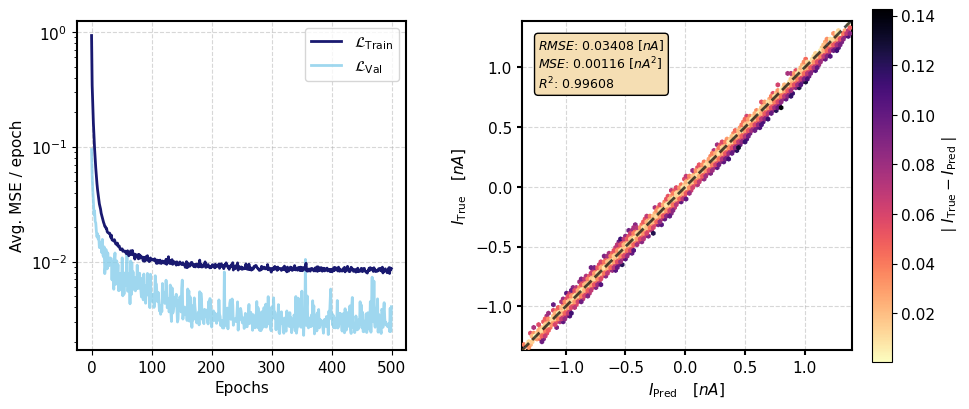

In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from utils import pred_vs_true  # only if you actually use it elsewhere

latex_txt_width = 404.02908 # in pt
in_per_pt = 1 / 72.27
width_in_pt = latex_txt_width * in_per_pt
height_in_pt = 0.618 * width_in_pt

import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 11,          # base font (affects cbar label unless overridden)
    "xtick.labelsize": 11,    # affects horizontal colorbar ticks
    "ytick.labelsize": 11,    # affects vertical colorbar ticks
    # Optional extras you may want:
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "legend.fontsize": 11,
})

# ---------------------------
# Run model on test set
# ---------------------------
model.eval()
model = model.to(device)

pred_params = []
y_true_l = []

with torch.no_grad():
    for v, y in test_loader:
        v = v.to(device, non_blocking=True, dtype=torch.float32)
        y = y.to(device, non_blocking=True, dtype=torch.float32)

        preds = model(v).detach().cpu().numpy()
        pred_params.append(preds)
        y_true_l.append(y.cpu().numpy())

# Take first parameter as prediction
y_pred_l = [params for params in pred_params]

scale = 1e0
y_pred = np.concatenate(y_pred_l, axis=0).ravel() * scale
y_true = np.concatenate(y_true_l, axis=0).ravel() * scale

# Range for diagonal and limits
lo = min(y_pred.min(), y_true.min())
hi = max(y_pred.max(), y_true.max())  # use max here, not min
print("lo, hi:", lo, hi)
plot_range = [[lo, hi], [lo, hi]]

# ---------------------------
# Create figure + axes
# ---------------------------
fig, ax = plt.subplots(ncols=2, figsize=(10, 5))

# Make both axes boxes square and same size
for a in ax:
    a.set_box_aspect(1)

# ---------------------------
# Left subplot: Losses
# ---------------------------
ax[0].plot(train_losses, c='midnightblue', zorder=5, label='$\mathcal{L}_{\mathrm{Train}}$', lw=2)
ax[0].plot(val_losses, c='skyblue', alpha=.8, zorder=4, label='$\mathcal{L}_{\mathrm{Val}}$', lw=2)
ax[0].grid(alpha=.5, ls='dashed')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Avg. MSE / epoch')
ax[0].legend()
ax[0].set_yscale('log')

for spine in ax[0].spines.values():
    spine.set_linewidth(1.5)

# ---------------------------
# Right subplot: Test set hexbin
# ---------------------------
pad = 0.0  # or e.g. hi * 0.1
ax[1].set_xlim(lo - pad, hi + pad)
ax[1].set_ylim(lo - pad, hi + pad)

#ax[1].set_xticks(np.linspace(lo, hi, 3))
#ax[1].set_yticks(np.linspace(lo, hi, 3))

residuals = y_pred - y_true           # or y_true - y_pred, just be consistent
abs_errors = np.abs(residuals)

im = ax[1].hexbin(
    y_pred,
    y_true,
    C=abs_errors,                    # values per point
    reduce_C_function=np.mean,       # aggregate: mean |error| in each bin
    gridsize=100,
    cmap="magma_r",                  # continuous colormap works well here
    # norm=LogNorm(),                # optional; linear is often easier to read
    zorder=5,
)

norm = LogNorm()

"""im = ax[1].hexbin(
    y_pred,
    y_true,
    bins=250,
    gridsize=100,
    norm=norm,
    cmap="RdBu_r",
    zorder=5,
)"""
ax[1].plot(
    [lo, hi],
    [lo, hi],
    linestyle='--',
    linewidth=2,
    color='k',
    alpha=0.7,
    zorder=6,
)

# Colorbar attached to BOTH axes (so they shrink equally),
# but made thinner/shorter so it doesn't look huge.
pos = ax[1].get_position()

# Create a custom colorbar axes with same height
cax = fig.add_axes([
    pos.x1 + 0.02,  # a bit to the right of ax[1]
    pos.y0,         # same bottom
    0.02,           # fixed width
    pos.height      # same height as ax[1] outer box
])

cbar = fig.colorbar(im, cax=cax)
cbar.set_label(r'$\mid I_{\mathrm{True}} - I_{\mathrm{Pred}} \mid$')

for spine in ax[1].spines.values():
    spine.set_linewidth(1.5)

ax[1].tick_params(direction='out', width=1.5)
ax[1].set_facecolor('w')
ax[1].grid(alpha=.5, ls='dashed')
ax[1].set_xlabel(r'$I_{\mathrm{Pred}} \quad [nA]$')
ax[1].set_ylabel(r'$I_{\mathrm{True}} \quad [nA]$')

# ---------------------------
# Metrics
# ---------------------------
mse = np.mean((y_true - y_pred) ** 2)
rmse = np.sqrt(mse)
R_sq = 1 - mse / np.var(y_true)  # standard R^2 definition

print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'R^2: {R_sq}')
print("y_true min/max/std:", y_true.min(), y_true.max(), y_true.std())

plot_text = (
    rf'$RMSE$: {rmse:.5f} $[nA]$'
    '\n'
    rf'$MSE$: {mse:.5f} $[nA^2]$'
    '\n'
    f'$R^2$: {R_sq:.5f}'
)

props = dict(boxstyle='round', facecolor='wheat', alpha=1)
ax[1].text(
    x=0.05,
    y=0.95,
    s=plot_text,
    transform=ax[1].transAxes,
    bbox=props,
    va='top',
    ha='left',
    zorder=6,
    fontsize=9
)
fig.subplots_adjust(wspace=0.35)
#plt.savefig('uni_baseline_model.pdf', bbox_inches='tight')
plt.show()

MAE: 0.02663183957338333
MAE / range(y): 0.9787659645080566 %


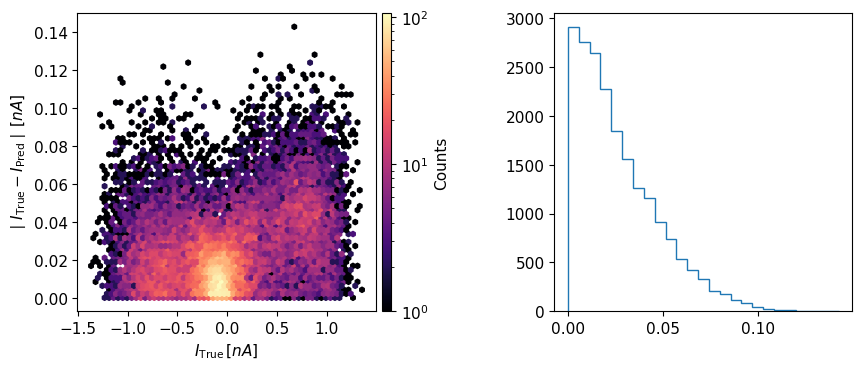

In [7]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

residuals = np.abs(y_true - y_pred)
mean_abs_residual = np.mean(residuals)
print(f'MAE: {mean_abs_residual}')
print(f'MAE / range(y): {100. * mean_abs_residual / (y_true.max() - y_true.min())} %')

fig, ax = plt.subplots(ncols=2, figsize=(10, 5))
im = ax[0].hexbin(y_true, residuals, gridsize=60, norm=norm, mincnt=1, cmap='magma')
for a in ax:
    a.set_box_aspect(1)
#ax[0].axhline(0.0, linestyle="--")
ax[0].set_xlabel(r"$I_{\mathrm{True}} \, [nA]$")
ax[0].set_ylabel(r"$\mid I_{\mathrm{True}} - I_{\mathrm{Pred}} \mid \, [nA]$")
#ax[0].set_aspect(1)

cax = inset_axes(ax[0],
                 width="3%",      # 3% of ax[0] width
                 height="100%",   # 100% of ax[0] height
                 loc="right",
                 borderpad=-1)

fig.colorbar(im, cax=cax, label="Counts")

bins = 25
ax[1].hist(residuals, histtype='step', density=False, bins=bins)

fig.subplots_adjust(wspace=0.6)
plt.show()